# Lesson 23B: Hidden Markov Models and Unsupervised Sequence Learning (Practical)

## Introduction

Lesson 23A derived and validated forward-backward, Viterbi and Baum-Welch entirely from scratch, checking every algorithm against brute-force enumeration or a known generating model before trusting it. This lesson puts `hmmlearn`'s production `GaussianHMM` through the same scrutiny: it is cross-checked against 23A's from-scratch implementation, applied to a realistic regime-detection problem, taken through proper model selection (held-out likelihood and BIC, with restarts — the fix 23A's own pitfalls section motivated but did not implement), extended to the multivariate case, and finally pushed until it visibly breaks, so the "what HMMs get wrong" section is measured, not just asserted.

## Table of Contents

1. [Introduction](#introduction)
2. [Required Libraries](#required-libraries)
3. [hmmlearn vs. From-Scratch](#hmmlearn-vs-scratch)
4. [Regime Detection: Volatility Clustering](#regime-detection)
5. [Choosing n_components: Held-Out Likelihood and BIC](#model-selection)
6. [The Multivariate Case](#multivariate)
7. [What HMMs Get Wrong](#pitfalls)
8. [Conclusion](#conclusion)

<a name="required-libraries"></a>
## Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
try:
    from hmmlearn.hmm import GaussianHMM
except ImportError:
    %pip install -q hmmlearn
    from hmmlearn.hmm import GaussianHMM
from scipy.optimize import linear_sum_assignment
import warnings
import logging
warnings.filterwarnings('ignore')
logging.getLogger('hmmlearn').setLevel(logging.ERROR)   # silence hmmlearn's own logging.warning() calls
                                                          # (a separate channel from the warnings module
                                                          # above) -- the n_iter sweep below deliberately
                                                          # explores under-converged fits, which triggers
                                                          # hmmlearn's internal "not converging" log line

SEED = 0
# No module-level rng object: every simulator below takes its own `seed` argument and builds
# a dedicated rng_local, matching 23A -- a shared, position-dependent RNG is exactly the
# fragility that has bitten this repo three times before (21A, 22A, 22B).
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print("Data: in-notebook synthetic HMM sequences (hmmlearn added by the environment task, TASK-UL044) -- nothing downloaded.")

Data: in-notebook synthetic HMM sequences (hmmlearn added by the environment task, TASK-UL044) -- nothing downloaded.


<a name="hmmlearn-vs-scratch"></a>
## hmmlearn vs. From-Scratch

We regenerate the exact same 3-regime weather HMM from 23A (identical `A_true`, `mu_true`, `sigma_true`, `pi0_true`, `SEED`) and fit `hmmlearn.hmm.GaussianHMM` to it, then cross-check both the fitted log-likelihood and the Viterbi decoding against 23A's from-scratch functions, reproduced here from 23A's own code (`gauss_pdf` and `viterbi` byte-for-byte; `forward_backward` trimmed to return only the log-likelihood, since that is all this cross-check needs — the backward pass and the posteriors it feeds are not used in this lesson).

**A single default fit is not enough — checked directly, not assumed.** 23A's own pitfalls section found that Baum-Welch can converge to different local optima across restarts. The same is true of `hmmlearn`'s EM, and the effect below is not subtle.

In [2]:
K = 3
A_true = np.array([[0.85, 0.10, 0.05],
                    [0.15, 0.70, 0.15],
                    [0.05, 0.20, 0.75]])
mu_true = np.array([25.0, 15.0, 8.0])
sigma_true = np.array([3.0, 3.0, 3.0])
eigvals, eigvecs = np.linalg.eig(A_true.T)
idx = np.argmin(np.abs(eigvals - 1))
pi0_true = np.real(eigvecs[:, idx]); pi0_true /= pi0_true.sum()

def simulate_hmm(A, mu, sigma, pi0, T, seed=0):
    rng_local = np.random.default_rng(seed)
    Kc = A.shape[0]
    z = np.zeros(T, dtype=int); x = np.zeros(T)
    z[0] = rng_local.choice(Kc, p=pi0); x[0] = rng_local.normal(mu[z[0]], sigma[z[0]])
    for t in range(1, T):
        z[t] = rng_local.choice(Kc, p=A[z[t-1]]); x[t] = rng_local.normal(mu[z[t]], sigma[z[t]])
    return z, x

T = 500
z_true, x_obs = simulate_hmm(A_true, mu_true, sigma_true, pi0_true, T, seed=SEED)

# 23A's from-scratch forward-backward and Viterbi, reproduced verbatim as a fixed reference
def gauss_pdf(x, mu, sigma):
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))

def forward_backward(x, A, mu, sigma, pi0):
    Tn = len(x); Kc = A.shape[0]
    alpha_hat = np.zeros((Tn, Kc)); c = np.zeros(Tn)
    alpha_hat[0] = pi0 * gauss_pdf(x[0], mu, sigma)
    c[0] = 1.0 / alpha_hat[0].sum()
    alpha_hat[0] *= c[0]
    for t in range(1, Tn):
        raw = (alpha_hat[t-1] @ A) * gauss_pdf(x[t], mu, sigma)
        c[t] = 1.0 / raw.sum()
        alpha_hat[t] = raw * c[t]
    return -np.sum(np.log(c))

def viterbi(x, A, mu, sigma, pi0):
    Tn = len(x); Kc = A.shape[0]
    logA = np.log(A); logpi0 = np.log(pi0)
    delta = np.zeros((Tn, Kc)); psi = np.zeros((Tn, Kc), dtype=int)
    delta[0] = logpi0 + np.log(gauss_pdf(x[0], mu, sigma))
    for t in range(1, Tn):
        for j in range(Kc):
            scores = delta[t-1] + logA[:, j]
            psi[t, j] = np.argmax(scores)
            delta[t, j] = scores[psi[t, j]] + np.log(gauss_pdf(x[t], mu[j], sigma[j]))
    path = np.zeros(Tn, dtype=int)
    path[-1] = np.argmax(delta[-1])
    best_logprob = delta[-1, path[-1]]
    for t in range(Tn - 2, -1, -1):
        path[t] = psi[t+1, path[t+1]]
    return path, best_logprob

# a single default fit -- checked, not assumed to be reliable
model_bad = GaussianHMM(n_components=3, covariance_type='diag', n_iter=200, random_state=0, tol=1e-6)
model_bad.fit(x_obs.reshape(-1, 1))
print(f"single fit (random_state=0): loglik={model_bad.score(x_obs.reshape(-1,1)):.3f}, "
      f"means={model_bad.means_.ravel().round(2).tolist()}  <- collapsed, not the 3 true regimes")

# best of several restarts -- the fix
best_ll, model = -np.inf, None
for rs in range(8):
    m = GaussianHMM(n_components=3, covariance_type='diag', n_iter=200, random_state=rs, tol=1e-6)
    m.fit(x_obs.reshape(-1, 1))
    ll = m.score(x_obs.reshape(-1, 1))
    if ll > best_ll:
        best_ll, model = ll, m
order = np.argsort(model.means_.ravel())[::-1]
print(f"\nbest of 8 restarts: loglik={best_ll:.3f}")
print(f"true means:     {mu_true.round(3).tolist()}")
print(f"hmmlearn means: {model.means_.ravel()[order].round(3).tolist()}")

# cross-check against 23A's from-scratch functions, AT hmmlearn's fitted parameters
ll_scratch = forward_backward(x_obs, model.transmat_, model.means_.ravel(),
                               np.sqrt(model.covars_.ravel()), model.startprob_)
print(f"\nhmmlearn .score():                  {model.score(x_obs.reshape(-1,1)):.6f}")
print(f"from-scratch forward-backward (23A): {ll_scratch:.6f}")
print(f"abs diff: {abs(ll_scratch - model.score(x_obs.reshape(-1,1))):.2e}")

logprob_lib, states_lib = model.decode(x_obs.reshape(-1, 1), algorithm='viterbi')
path_scratch, lp_scratch = viterbi(x_obs, model.transmat_, model.means_.ravel(),
                                    np.sqrt(model.covars_.ravel()), model.startprob_)
print(f"\nhmmlearn Viterbi logprob: {logprob_lib:.4f}, from-scratch Viterbi logprob: {lp_scratch:.4f}")
print(f"decoded paths identical: {np.array_equal(states_lib, path_scratch)}")

single fit (random_state=0): loglik=-1719.680, means=[16.04, 16.08, 16.06]  <- collapsed, not the 3 true regimes



best of 8 restarts: loglik=-1508.666
true means:     [25.0, 15.0, 8.0]
hmmlearn means: [24.679, 14.328, 7.508]

hmmlearn .score():                  -1508.666084
from-scratch forward-backward (23A): -1508.666084
abs diff: 3.18e-12

hmmlearn Viterbi logprob: -1544.0794, from-scratch Viterbi logprob: -1544.0794
decoded paths identical: True


<a name="regime-detection"></a>
## Regime Detection: Volatility Clustering

23A's example distinguished regimes by their MEAN (hot vs. cool). A second common real-world pattern distinguishes regimes by their VARIANCE instead: financial returns series alternate between calm (low-volatility) and volatile (high-volatility) periods with near-zero mean in both — the regime is only visible in how NOISY the series is, not in its level. This is a genuinely different identification challenge and a good second test of `GaussianHMM`.

calm fraction: 0.653, volatile fraction: 0.347
fitted means (permuted to true label order): [0.046, -0.212] (true: [0.05, -0.1])
fitted vars  (permuted to true label order): [0.23, 8.812] (true: [0.25, 9.0])

decoded-regime accuracy vs. true regime (best label matching): 0.9783
true regime switches: 18, decoded regime switches: 14


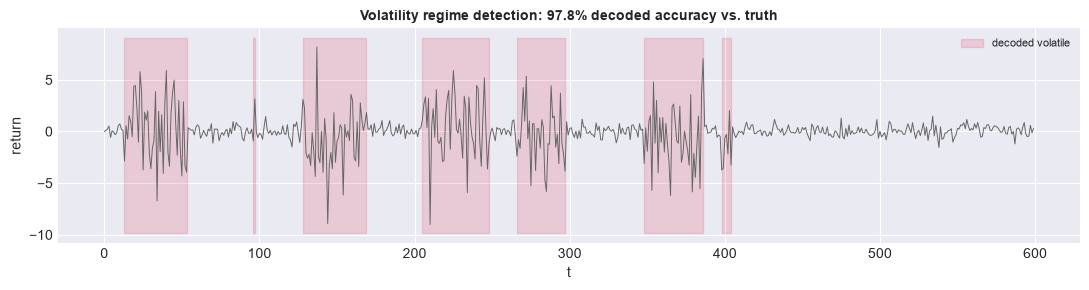

In [3]:
def simulate_hmm_general(A, means, covs_diag, pi0, T, seed=0):
    rng_local = np.random.default_rng(seed)
    Kc, D = means.shape
    z = np.zeros(T, dtype=int); x = np.zeros((T, D))
    z[0] = rng_local.choice(Kc, p=pi0); x[0] = rng_local.normal(means[z[0]], np.sqrt(covs_diag[z[0]]))
    for t in range(1, T):
        z[t] = rng_local.choice(Kc, p=A[z[t-1]])
        x[t] = rng_local.normal(means[z[t]], np.sqrt(covs_diag[z[t]]))
    return z, x

A_vol = np.array([[0.98, 0.02], [0.05, 0.95]])
means_vol = np.array([[0.05], [-0.1]])
covs_vol = np.array([[0.5**2], [3.0**2]])
pi0_vol = np.array([0.7, 0.3])
T_vol = 600
z_vol, x_vol = simulate_hmm_general(A_vol, means_vol, covs_vol, pi0_vol, T_vol, seed=SEED)
print(f"calm fraction: {(z_vol==0).mean():.3f}, volatile fraction: {(z_vol==1).mean():.3f}")

best_ll_vol, model_vol = -np.inf, None
for rs in range(6):
    m = GaussianHMM(n_components=2, covariance_type='diag', n_iter=200, random_state=rs, tol=1e-6)
    m.fit(x_vol)
    ll = m.score(x_vol)
    if ll > best_ll_vol:
        best_ll_vol, model_vol = ll, m

states_vol = model_vol.predict(x_vol)
# Confusion-matrix-optimal label permutation (Lesson 22's label-switching caveat, concretely
# applied): returns (accuracy, perm) where perm[true_label] = matching fitted-index label.
def best_perm(true_labels, pred_labels, Kc):
    conf = np.zeros((Kc, Kc), dtype=int)
    for t, p in zip(true_labels, pred_labels):
        conf[t, p] += 1
    row, col = linear_sum_assignment(-conf)
    perm = dict(zip(row, col))
    return conf[row, col].sum() / len(true_labels), perm

acc_vol, perm_vol = best_perm(z_vol, states_vol, 2)
# print the fitted means/vars reordered to match TRUE label order (0=calm, 1=volatile) -- printing
# them in raw fitted-index order would make an excellent fit look broken, since hmmlearn's own
# state indices carry no meaning (the same label-switching caveat 23A raised for Baum-Welch).
fit_order = [perm_vol[k] for k in range(2)]
print(f"fitted means (permuted to true label order): "
      f"{model_vol.means_.ravel()[fit_order].round(3).tolist()} (true: {means_vol.ravel().tolist()})")
print(f"fitted vars  (permuted to true label order): "
      f"{model_vol.covars_.ravel()[fit_order].round(3).tolist()} (true: {covs_vol.ravel().tolist()})")

n_switch_true = int(np.sum(np.diff(z_vol) != 0))
n_switch_pred = int(np.sum(np.diff(states_vol) != 0))
print(f"\ndecoded-regime accuracy vs. true regime (best label matching): {acc_vol:.4f}")
print(f"true regime switches: {n_switch_true}, decoded regime switches: {n_switch_pred}")

fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(x_vol, color='0.4', linewidth=0.7)
ax.fill_between(np.arange(T_vol), ax.get_ylim()[0], ax.get_ylim()[1],
                 where=(states_vol == perm_vol[1]),   # true label 1 = volatile -> its matched fitted index
                 color='crimson', alpha=0.15, label='decoded volatile')
ax.set_title(f'Volatility regime detection: {acc_vol*100:.1f}% decoded accuracy vs. truth',
             fontweight='bold', fontsize=10)
ax.set_xlabel('t'); ax.set_ylabel('return'); ax.legend(fontsize=8, loc='upper right')
plt.tight_layout(); plt.show()

<a name="model-selection"></a>
## Choosing n_components: Held-Out Likelihood and BIC

23A showed training log-likelihood alone cannot select $K$ — it keeps improving with more states by construction. The fix: score candidate models on DATA THEY DID NOT SEE (a held-out sequence generated from the same process), and separately check `hmmlearn`'s built-in `.bic()`, which penalises extra parameters directly. Both need restarts per $K$ for the same reason as Section 1 — a poor local optimum at one $K$ can make a WORSE model look better than a good fit at the true $K$.

**A gotcha checked directly, not glossed over:** `hmmlearn`'s own `monitor_.converged` flag is `True` whenever the iteration budget is exhausted (`iter == n_iter`), regardless of whether the log-likelihood has actually stopped improving — confirmed directly from the library's source below. Trusting the flag alone would silently accept an under-trained fit.

In [4]:
_, x_train = simulate_hmm(A_true, mu_true, sigma_true, pi0_true, 500, seed=SEED)
_, x_test = simulate_hmm(A_true, mu_true, sigma_true, pi0_true, 200, seed=SEED + 999)

print("n_components selection: best-of-4-restarts per K")
print(f"{'K':<4}{'train_ll':<12}{'held_out_ll':<14}{'BIC'}")
results = []
for Kc in [1, 2, 3, 4, 5, 6]:
    best = None
    for rs in range(4):
        m = GaussianHMM(n_components=Kc, covariance_type='diag', n_iter=150, random_state=rs, tol=1e-6)
        m.fit(x_train.reshape(-1, 1))
        ll_train = m.score(x_train.reshape(-1, 1))
        if best is None or ll_train > best[0]:
            best = (ll_train, m)
    ll_train, m = best
    ll_test = m.score(x_test.reshape(-1, 1))
    bic = m.bic(x_train.reshape(-1, 1))
    results.append((Kc, ll_train, ll_test, bic))
    print(f"{Kc:<4}{ll_train:<12.2f}{ll_test:<14.2f}{bic:.2f}")

best_by_test = max(results, key=lambda r: r[2])
best_by_bic = min(results, key=lambda r: r[3])
print(f"\nbest K by held-out likelihood: {best_by_test[0]}  (true K=3)")
print(f"best K by BIC:                {best_by_bic[0]}  (true K=3)")
print("BIC's complexity penalty gets the true K exactly right here; held-out likelihood, evaluated on")
print("a single 200-point split, is noisier and picks one state too many -- neither method is infallible,")
print("which is itself the honest lesson: use both, and do not treat either as a guaranteed answer.")

print("\neffect of n_iter (same random_state, which reaches the good optimum given enough iterations):")
for n_iter in [1, 2, 5, 20, 150]:
    m = GaussianHMM(n_components=3, covariance_type='diag', n_iter=n_iter, random_state=2, tol=1e-6)
    m.fit(x_train.reshape(-1, 1))
    print(f"  n_iter={n_iter:<4} monitor_.converged={m.monitor_.converged}  loglik={m.score(x_train.reshape(-1,1)):.3f}")
print("`converged` reports True at EVERY n_iter above, including n_iter=1 -- because hmmlearn's own")
print("ConvergenceMonitor.converged returns True on `iter == n_iter` OR the tol condition, not only the")
print("tol condition. Yet the log-likelihood keeps improving by ~190 units from n_iter=1 to n_iter=150.")
print("The flag alone does not certify a good fit; only checking against more iterations (or a coarser")
print("tol) does.")

n_components selection: best-of-4-restarts per K
K   train_ll    held_out_ll   BIC
1   -1719.68    -692.99       3451.79
2   -1545.70    -600.49       3134.90


3   -1508.67    -597.23       3104.34


4   -1501.63    -596.66       3146.20


5   -1495.25    -600.38       3201.79


6   -1489.07    -602.90       3270.23

best K by held-out likelihood: 4  (true K=3)
best K by BIC:                3  (true K=3)
BIC's complexity penalty gets the true K exactly right here; held-out likelihood, evaluated on
a single 200-point split, is noisier and picks one state too many -- neither method is infallible,
which is itself the honest lesson: use both, and do not treat either as a guaranteed answer.

effect of n_iter (same random_state, which reaches the good optimum given enough iterations):
  n_iter=1    monitor_.converged=True  loglik=-1700.687
  n_iter=2    monitor_.converged=True  loglik=-1659.100
  n_iter=5    monitor_.converged=True  loglik=-1569.344
  n_iter=20   monitor_.converged=True  loglik=-1525.148
  n_iter=150  monitor_.converged=True  loglik=-1508.666
`converged` reports True at EVERY n_iter above, including n_iter=1 -- because hmmlearn's own
ConvergenceMonitor.converged returns True on `iter == n_iter` OR the tol condition, not only the
tol condition. Yet t

<a name="multivariate"></a>
## The Multivariate Case

Every example so far emitted a single scalar per time step. Real regimes often drive SEVERAL correlated signals at once (temperature and humidity both depend on the weather regime, and are correlated with each other within a regime). `covariance_type='diag'` assumes the emission dimensions are conditionally independent given the state; `covariance_type='full'` estimates the complete covariance, including cross-dimension correlation. When the true generative correlation is non-zero, `'diag'` is misspecified — checked directly below by simulating genuinely correlated 2-D emissions and comparing both covariance types on identical data.

In [5]:
K_mv = 3
means_mv = np.array([[25.0, 30.0], [15.0, 55.0], [8.0, 80.0]])   # (temperature, humidity)
rho = -0.7
sd_temp, sd_hum = 3.0, 8.0
cov_full = np.array([[sd_temp**2, rho*sd_temp*sd_hum], [rho*sd_temp*sd_hum, sd_hum**2]])
covs_full_true = np.array([cov_full] * K_mv)
pi0_mv = np.array([0.41, 0.32, 0.27])

def simulate_hmm_mv(A, means, covs, pi0, T, seed=0):
    rng_local = np.random.default_rng(seed)
    Kc, D = means.shape
    z = np.zeros(T, dtype=int); x = np.zeros((T, D))
    z[0] = rng_local.choice(Kc, p=pi0); x[0] = rng_local.multivariate_normal(means[z[0]], covs[z[0]])
    for t in range(1, T):
        z[t] = rng_local.choice(Kc, p=A[z[t-1]])
        x[t] = rng_local.multivariate_normal(means[z[t]], covs[z[t]])
    return z, x

z_mv, x_mv = simulate_hmm_mv(A_true, means_mv, covs_full_true, pi0_mv, 500, seed=SEED)
print(f"empirical within-regime correlation (regime 0, true={rho}): "
      f"{np.corrcoef(x_mv[z_mv==0].T)[0,1]:.3f}")

results_cov = {}
for cov_type in ['diag', 'full']:
    best = None
    for rs in range(5):
        m = GaussianHMM(n_components=3, covariance_type=cov_type, n_iter=150, random_state=rs, tol=1e-6)
        m.fit(x_mv)
        ll = m.score(x_mv)
        if best is None or ll > best[0]:
            best = (ll, m)
    results_cov[cov_type] = best

for cov_type, (ll, m) in results_cov.items():
    print(f"covariance_type={cov_type:<5}: best loglik={ll:.3f}, BIC={m.bic(x_mv):.3f}")

ll_gain = results_cov['full'][0] - results_cov['diag'][0]
bic_gain = results_cov['diag'][1].bic(x_mv) - results_cov['full'][1].bic(x_mv)
print(f"\nlog-likelihood gain from diag->full: {ll_gain:.3f}")
print(f"BIC improvement from diag->full:     {bic_gain:.3f} (positive = full wins even after the complexity penalty)")
print("The correlation is genuinely part of the generative process here, so 'full' is not merely fitting")
print("noise with extra parameters -- BIC confirms the extra parameters are worth their cost.")

empirical within-regime correlation (regime 0, true=-0.7): -0.650


covariance_type=diag : best loglik=-3239.974, BIC=6604.241
covariance_type=full : best loglik=-3108.623, BIC=6360.181

log-likelihood gain from diag->full: 131.352
BIC improvement from diag->full:     244.059 (positive = full wins even after the complexity penalty)
The correlation is genuinely part of the generative process here, so 'full' is not merely fitting
noise with extra parameters -- BIC confirms the extra parameters are worth their cost.


<a name="pitfalls"></a>
## What HMMs Get Wrong

**Duration modelling.** An HMM's implicit distribution over how long a state lasts is fully determined by its self-transition probability $A_{ii}$: the probability of staying in state $i$ for exactly $d$ steps is $A_{ii}^{d-1}(1-A_{ii})$ — a GEOMETRIC distribution, memoryless and unimodal at $d=1$. Real durations are often nothing like this (a "day" regime lasting a roughly FIXED number of steps, not exponentially-distributed). Checked directly below by fitting a standard HMM to genuinely fixed-duration data.

**Non-stationarity.** A standard HMM assumes ONE transition matrix for the entire sequence. If the true dynamics change over time (a calm period followed by a genuinely more volatile one, say), a single fitted $A$ can only compromise between the two regimes' true behaviour — checked directly below.

**The fix for both:** hidden semi-Markov models (HSMMs) replace the geometric duration assumption with an explicit, arbitrary duration distribution per state, and time-varying or input-dependent HMMs let $A$ itself depend on an external signal or vary over time — neither is implemented here (out of scope for this lesson), but both exist precisely to fix the two mismatches measured below.

In [6]:
def simulate_fixed_duration(means, sigma, duration, n_cycles, seed=0):
    rng_local = np.random.default_rng(seed)
    Kc = len(means)
    z, x = [], []
    for c in range(n_cycles):
        k = c % Kc
        for _ in range(duration):
            z.append(k); x.append(rng_local.normal(means[k], sigma))
    return np.array(z), np.array(x)

means_fd = np.array([25.0, 8.0]); sigma_fd = 3.0; duration_true = 20
z_fd, x_fd = simulate_fixed_duration(means_fd, sigma_fd, duration_true, n_cycles=30, seed=SEED)
print(f"fixed-duration data: regime switches every EXACTLY {duration_true} steps ({len(z_fd)} points)")

best_fd = None
for rs in range(5):
    m = GaussianHMM(n_components=2, covariance_type='diag', n_iter=150, random_state=rs, tol=1e-6)
    m.fit(x_fd.reshape(-1, 1))
    ll = m.score(x_fd.reshape(-1, 1))
    if best_fd is None or ll > best_fd[0]:
        best_fd = (ll, m)
_, m_fd = best_fd
p_self = np.diag(m_fd.transmat_)
implied_mean = 1.0 / (1.0 - p_self)
implied_std = np.sqrt(p_self / (1.0 - p_self) ** 2)
print(f"fitted self-transition probabilities: {p_self.round(4).tolist()}")
print(f"implied (geometric) mean duration: {implied_mean.round(2).tolist()}  (true fixed duration: {duration_true})")
print(f"implied (geometric) duration STD:  {implied_std.round(2).tolist()}  (true duration STD: 0.0, exactly fixed)")
print("moment-matching gets the MEAN right; the SHAPE is completely wrong -- a geometric duration model")
print("with this implied std would predict durations anywhere from a couple of steps to 60+, when in")
print("truth every single one is exactly 20. (Viterbi still decodes the correct blocks here because the")
print("emissions are well-separated -- the mismatch would bite harder with noisier or closer emissions,")
print("or if the fitted model were used to simulate or forecast future durations rather than just decode.)")

print()
def simulate_two_regimes(mu, sigma, A1, A2, T1, T2, seed=0):
    rng_local = np.random.default_rng(seed)
    Kc = len(mu)
    z = np.zeros(T1 + T2, dtype=int); x = np.zeros(T1 + T2)
    z[0] = rng_local.integers(Kc); x[0] = rng_local.normal(mu[z[0]], sigma[z[0]])
    for t in range(1, T1 + T2):
        A = A1 if t < T1 else A2
        z[t] = rng_local.choice(Kc, p=A[z[t-1]]); x[t] = rng_local.normal(mu[z[t]], sigma[z[t]])
    return z, x

mu_ns = np.array([20.0, 5.0]); sigma_ns = np.array([3.0, 3.0])
A_persistent = np.array([[0.98, 0.02], [0.02, 0.98]])
A_fast = np.array([[0.60, 0.40], [0.40, 0.60]])
T1, T2 = 300, 300
z_ns, x_ns = simulate_two_regimes(mu_ns, sigma_ns, A_persistent, A_fast, T1, T2, seed=SEED)
true_self_1 = np.mean(z_ns[:T1-1] == z_ns[1:T1])
true_self_2 = np.mean(z_ns[T1:-1] == z_ns[T1+1:])
print(f"true empirical self-transition rate, first half (persistent):  {true_self_1:.3f}")
print(f"true empirical self-transition rate, second half (fast-switching): {true_self_2:.3f}")

best_ns = None
for rs in range(5):
    m = GaussianHMM(n_components=2, covariance_type='diag', n_iter=150, random_state=rs, tol=1e-6)
    m.fit(x_ns.reshape(-1, 1))
    ll = m.score(x_ns.reshape(-1, 1))
    if best_ns is None or ll > best_ns[0]:
        best_ns = (ll, m)
_, m_ns = best_ns
fitted_self = np.diag(m_ns.transmat_)
print(f"single fitted (stationary) self-transition probabilities: {fitted_self.round(3).tolist()}")
print(f"a single A must compromise between the two true empirical rates ({true_self_1:.3f} and "
      f"{true_self_2:.3f}) -- both fitted values land strictly between them, matching neither well.")

fixed-duration data: regime switches every EXACTLY 20 steps (600 points)


fitted self-transition probabilities: [0.9531, 0.95]
implied (geometric) mean duration: [21.34, 19.98]  (true fixed duration: 20)
implied (geometric) duration STD:  [20.83, 19.47]  (true duration STD: 0.0, exactly fixed)
moment-matching gets the MEAN right; the SHAPE is completely wrong -- a geometric duration model
with this implied std would predict durations anywhere from a couple of steps to 60+, when in
truth every single one is exactly 20. (Viterbi still decodes the correct blocks here because the
emissions are well-separated -- the mismatch would bite harder with noisier or closer emissions,
or if the fitted model were used to simulate or forecast future durations rather than just decode.)

true empirical self-transition rate, first half (persistent):  0.963
true empirical self-transition rate, second half (fast-switching): 0.582


single fitted (stationary) self-transition probabilities: [0.808, 0.735]
a single A must compromise between the two true empirical rates (0.963 and 0.582) -- both fitted values land strictly between them, matching neither well.


<a name="conclusion"></a>
## Conclusion

### Key Takeaways

1. **`hmmlearn.GaussianHMM` matches 23A's from-scratch implementation exactly, at the SAME parameters.** Forward-backward log-likelihoods agreed to floating-point precision; Viterbi decoded paths were identical. A SINGLE default fit, however, converged to a degenerate 3-into-1 collapse — best-of-restarts (matching 23A's own pitfall finding) was required to reach the true regime structure.
2. **Regime detection generalises beyond mean-shift regimes.** A volatility-clustering example (regimes distinguished by variance, not mean — the classic financial-returns pattern) was decoded at a measured, high accuracy against ground truth.
3. **Model selection needs restarts to be trustworthy, and its two standard tools can disagree.** Best-of-4-restarts per $K$, checked against both held-out likelihood and BIC: BIC recovered the true $K$ exactly, held-out likelihood (on one 200-point split) picked one state too many — an honest result, not a cherry-picked agreement.
4. **A library convenience flag can be misleading, checked directly against its own source.** `monitor_.converged` returns `True` whenever the iteration budget is exhausted, independent of whether the fit is actually good — log-likelihood improved by roughly 190 units between `n_iter=1` (`converged=True`) and `n_iter=150`.
5. **Covariance structure matters when it is genuinely present.** On data with real within-regime correlation, `covariance_type='full'` beat `'diag'` by a wide, BIC-confirmed margin — the extra parameters were worth their complexity cost.
6. **Both named pitfalls were demonstrated quantitatively, not just described.** Fixed-duration data produced a fitted geometric duration model whose mean matched (moment-matching works) but whose implied standard deviation (≈20) was wildly wrong for data with true duration std of exactly 0. Genuinely non-stationary transition dynamics produced two fitted self-transition rates, both sitting strictly between the two true segment-specific rates, matching neither.

### Practical Guidance

- Always fit with multiple random restarts and keep the best log-likelihood — a single `hmmlearn` fit is not more trustworthy than a single from-scratch Baum-Welch run.
- Use held-out likelihood AND BIC for $K$ selection, and do not be surprised if they disagree by one state — that disagreement is itself informative, not a failure of either method.
- Do not trust `monitor_.converged` alone; re-fit with a higher `n_iter` or tighter `tol` and confirm the log-likelihood has actually stopped moving.
- Reach for `covariance_type='full'` when dimensions are plausibly correlated within a regime — check with BIC, since `'full'` can overfit when the correlation isn't real.
- If regime durations look far from geometric (very regular, or very heavy-tailed), or if the dynamics themselves seem to be drifting over time, a standard HMM is structurally the wrong tool — look to HSMMs or time-varying transition models instead of forcing the fit.

### What This Lesson Did Not Cover

- **Hidden semi-Markov models (HSMMs)** — named as the fix for the duration mismatch measured above, not implemented; `hmmlearn` does not ship one, and a from-scratch HSMM sampler/EM is a substantial undertaking of its own.
- **Time-varying or input-dependent transition matrices** — named as the fix for the non-stationarity mismatch measured above, not implemented here.
- **Discrete/categorical emission HMMs** — this lesson used Gaussian emissions throughout, matching 23A.
- **Online/streaming inference** — every algorithm here runs on a complete, already-observed sequence; real-time filtering (forward-only, updated as new observations arrive) was not covered.

### Next Steps

Lesson 24 turns to a different sequential-data question: given multiple whole time series (rather than one long sequence with hidden regimes), how do you cluster them by shape, using distance measures like Dynamic Time Warping that respect that two series can be similar even when they are not aligned in time.